# Practical Session 03a — The bias–variance trade-off, simulated

**Companion to Lecture 03.** Session 02 showed *that* a model can under- or over-fit; here we make
the **bias–variance decomposition** concrete by running the lecture's *thought experiment* in code:
draw many fresh training sets, refit the same model on each, and **measure** bias and variance
directly.

* the **thought experiment** — resample, refit, and look at the *family* of fits and their average;
* **simple vs flexible** — high bias / low variance vs low bias / high variance;
* a **Monte-Carlo** estimate of bias², variance, and noise, verifying
  $\mathbb{E}[(y-\hat f)^2]=\text{bias}^2+\text{variance}+\sigma^2$;
* the **U-curve**: sweep complexity and watch bias² fall while variance rises.

> ⭐ **Key idea.** The error on fresh data splits into three parts: **bias²** (how far the *average*
> fit sits from the truth), **variance** (how much the fit *wobbles* as the training set changes),
> and **irreducible noise** $\sigma^2$. More flexibility trades bias for variance — the sweet spot
> minimizes their sum.

*Run each cell (Shift+Enter). Self-contained and offline.*

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Chebyshev

from nb_utils import use_style
use_style("notes")
np.set_printoptions(precision=3, suppress=True)

# The true pattern we try to recover, and the noise around it.
def truth(x):
    return np.sin(2 * np.pi * x)

NOISE_SD = 0.18          # sigma of the observation noise
BLUE, ORANGE, GREEN, GRAY = "#0072B2", "#D55E00", "#117733", "#7F7F7F"
xg = np.linspace(0, 1, 300)          # a dense grid for plotting / evaluation
print("ready")

ready


## 1. The thought experiment: resample & refit

We only ever *see* one training set. But imagine drawing **many fresh training sets** from the same
process $y=f(x)+\varepsilon$ and refitting the *same* model family on each. Each fresh dataset gives a
slightly different fit; together they form a *family* whose **average** is
$\bar f(x)=\mathbb{E}[\hat f(x)]$. (We use the Chebyshev basis — same polynomials, but numerically
well-behaved at high degree.)

C:\Users\JAN\AppData\Local\Temp\ipykernel_47044\1146077199.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


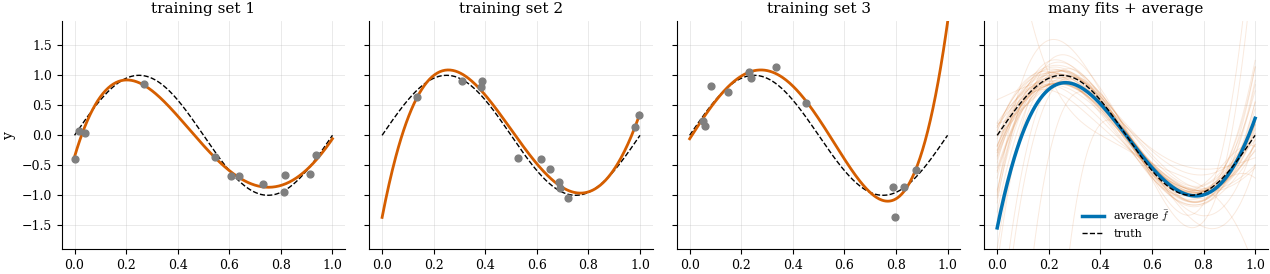

In [2]:
def sample(rng, n=12):
    # a fresh training set: new random x locations and new noise
    x = np.sort(rng.uniform(0, 1, n))
    return x, truth(x) + NOISE_SD * rng.standard_normal(n)

DEG = 4
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 4, figsize=(13, 3), sharex=True, sharey=True)
for i, ax in enumerate(axes[:3]):                 # three DIFFERENT training sets, each its own fit
    x, y = sample(rng)
    fit = Chebyshev.fit(x, y, DEG, domain=[0, 1])
    ax.plot(xg, truth(xg), "--", color="black", lw=1)
    ax.plot(xg, fit(xg), color=ORANGE, lw=2)
    ax.scatter(x, y, s=24, color=GRAY, zorder=3)
    ax.set_title(f"training set {i+1}"); ax.set_ylim(-1.9, 1.9)

preds = np.array([Chebyshev.fit(*sample(rng), DEG, domain=[0, 1])(xg) for _ in range(40)])
axes[3].plot(xg, preds.T, color=ORANGE, alpha=0.13, lw=0.7)
axes[3].plot(xg, preds.mean(0), color=BLUE, lw=2.5, label=r"average $\bar f$")
axes[3].plot(xg, truth(xg), "--", color="black", lw=1, label="truth")
axes[3].set_title("many fits + average"); axes[3].legend(fontsize=8)
axes[0].set_ylabel("y")
plt.tight_layout(); plt.show()

## 2. Simple vs flexible: the two ways to be wrong

A **simple** model (low degree) gives fits that cluster tightly but miss the truth — **low variance,
high bias**. A **flexible** model (high degree) gives fits that scatter wildly but average out near
the truth — **high variance, low bias**. We estimate each number by resampling.

C:\Users\JAN\AppData\Local\Temp\ipykernel_47044\3312196559.py:15: UserWarning: The figure layout has changed to tight
  plt.tight_layout(); plt.show()


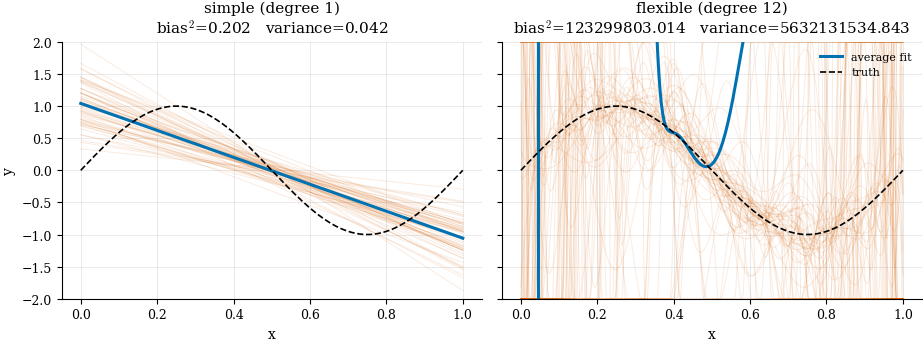

In [3]:
def family(deg, n_sets=60, n=15):
    rng = np.random.default_rng(1)                 # same noise draws for both models -> fair compare
    return np.array([Chebyshev.fit(*sample(rng, n), deg, domain=[0, 1])(xg) for _ in range(n_sets)])

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.7), sharey=True)
for ax, deg, name in [(axes[0], 1, "simple (degree 1)"), (axes[1], 12, "flexible (degree 12)")]:
    P = family(deg)
    b2 = np.mean((P.mean(0) - truth(xg)) ** 2); var = np.mean(P.var(0))
    ax.plot(xg, np.clip(P.T, -2, 2), color=ORANGE, alpha=0.12, lw=0.7)
    ax.plot(xg, P.mean(0), color=BLUE, lw=2.2, label="average fit")
    ax.plot(xg, truth(xg), "--", color="black", lw=1.2, label="truth")
    ax.set_title(f"{name}\nbias$^2$={b2:.3f}   variance={var:.3f}")
    ax.set_ylim(-2, 2); ax.set_xlabel("x")
axes[0].set_ylabel("y"); axes[1].legend(fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

## 3. Measuring the three terms (Monte-Carlo)

Fix the design points (only the noise is resampled — the standard, well-conditioned setup) and refit
many times. At each test point we estimate the **average prediction** $\bar f$, then

$$\text{bias}^2=\overline{(\bar f-f)^2},\qquad \text{variance}=\overline{\operatorname{Var}[\hat f]},
\qquad \sigma^2=\text{noise variance}.$$

Finally we check they sum to the **directly measured** expected test error.

In [4]:
rng = np.random.default_rng(3)
n_sets, deg = 400, 5
xt = np.linspace(0, 1, 25)              # FIXED design points
ft = truth(xt)
f_grid = truth(xg)

preds = np.empty((n_sets, xg.size))
for s in range(n_sets):
    yt = ft + NOISE_SD * rng.standard_normal(xt.size)     # only the noise changes
    preds[s] = Chebyshev.fit(xt, yt, deg, domain=[0, 1])(xg)

fbar     = preds.mean(0)
bias2    = np.mean((fbar - f_grid) ** 2)
variance = np.mean(preds.var(0))
sigma2   = NOISE_SD ** 2

# directly measured expected test MSE: fresh noisy targets vs each fit
y_fresh  = f_grid + NOISE_SD * rng.standard_normal((n_sets, xg.size))
test_mse = np.mean((y_fresh - preds) ** 2)

print(f"bias^2            = {bias2:.4f}")
print(f"variance          = {variance:.4f}")
print(f"sigma^2           = {sigma2:.4f}")
print(f"sum of the three  = {bias2 + variance + sigma2:.4f}")
print(f"measured test MSE = {test_mse:.4f}   <- matches the sum")

bias^2            = 0.0000
variance          = 0.0071
sigma^2           = 0.0324
sum of the three  = 0.0395
measured test MSE = 0.0395   <- matches the sum


## 4. The U-curve: sweep the complexity

Repeat the measurement across polynomial degrees. **Bias²** falls as the model gets more flexible;
**variance** rises. Their sum (plus the noise floor) is the familiar **U**, whose minimum is the best
complexity — exactly the curve the lecture dissects.

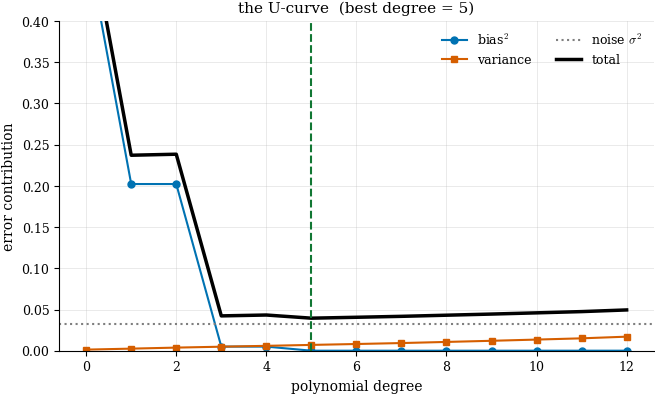

In [5]:
degrees = np.arange(0, 13)
B2, V = [], []
for d in degrees:
    rng = np.random.default_rng(0)                 # same noise sequence across degrees
    P = np.array([Chebyshev.fit(xt, ft + NOISE_SD * rng.standard_normal(xt.size),
                                int(d), domain=[0, 1])(xg) for _ in range(300)])
    B2.append(np.mean((P.mean(0) - f_grid) ** 2)); V.append(np.mean(P.var(0)))
B2, V = np.array(B2), np.array(V)
total = B2 + V + sigma2
best = degrees[int(np.argmin(total))]

plt.figure(figsize=(6.6, 4))
plt.plot(degrees, B2, "-o", color=BLUE, label="bias$^2$")
plt.plot(degrees, V, "-s", color=ORANGE, label="variance")
plt.axhline(sigma2, ls=":", color=GRAY, label=r"noise $\sigma^2$")
plt.plot(degrees, total, "-", color="black", lw=2.5, label="total")
plt.axvline(best, ls="--", color=GREEN)
plt.xlabel("polynomial degree"); plt.ylabel("error contribution")
plt.ylim(0, 0.4); plt.legend(ncol=2); plt.title(f"the U-curve  (best degree = {best})")
plt.show()

> 🔬 **Going deeper.** We *measured* the decomposition; the lecture *derives* it. Writing
> $y-\hat f=(f-\bar f)+(\bar f-\hat f)+\varepsilon$ and squaring, every cross term carries a
> mean-zero, independent factor and vanishes, leaving exactly
> $\mathbb{E}[(y-\hat f)^2]=(\bar f-f)^2+\mathbb{E}[(\hat f-\bar f)^2]+\sigma^2$
> $=\text{bias}^2+\text{variance}+\sigma^2$.

## Recap & exercises

**Recap.**
* The **thought experiment** — resample, refit — turns bias and variance into things you can *see*
  and *measure*.
* **Bias²** = squared offset of the average fit; **variance** = spread of the fits; **σ²** =
  irreducible noise. They add up to the expected test error.
* Sweeping complexity traces the **U**: bias² down, variance up, minimum at the sweet spot.

**Exercises.**
1. Raise `NOISE_SD`. Which term(s) move, and where does the best degree go?
2. In Section 3, shrink `n_sets` to `20`. Does the Monte-Carlo estimate get noisier? Why?
3. Add a heavier-tailed noise (e.g. Student-t) and recompute the U-curve — does the sweet spot move?
4. Replace `Chebyshev.fit` with `np.polyfit`. At high degree the variance explodes — why is the
   Chebyshev basis better conditioned?

*Next:* **03b — Regularization from scratch (ridge & lasso)**, which *steers* the trade-off by
penalizing large weights.